<a href="https://colab.research.google.com/github/AI-is-out-there/FDA-AI-products-as-graph/blob/main/code/Graph-FDA-timeline-intereactive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


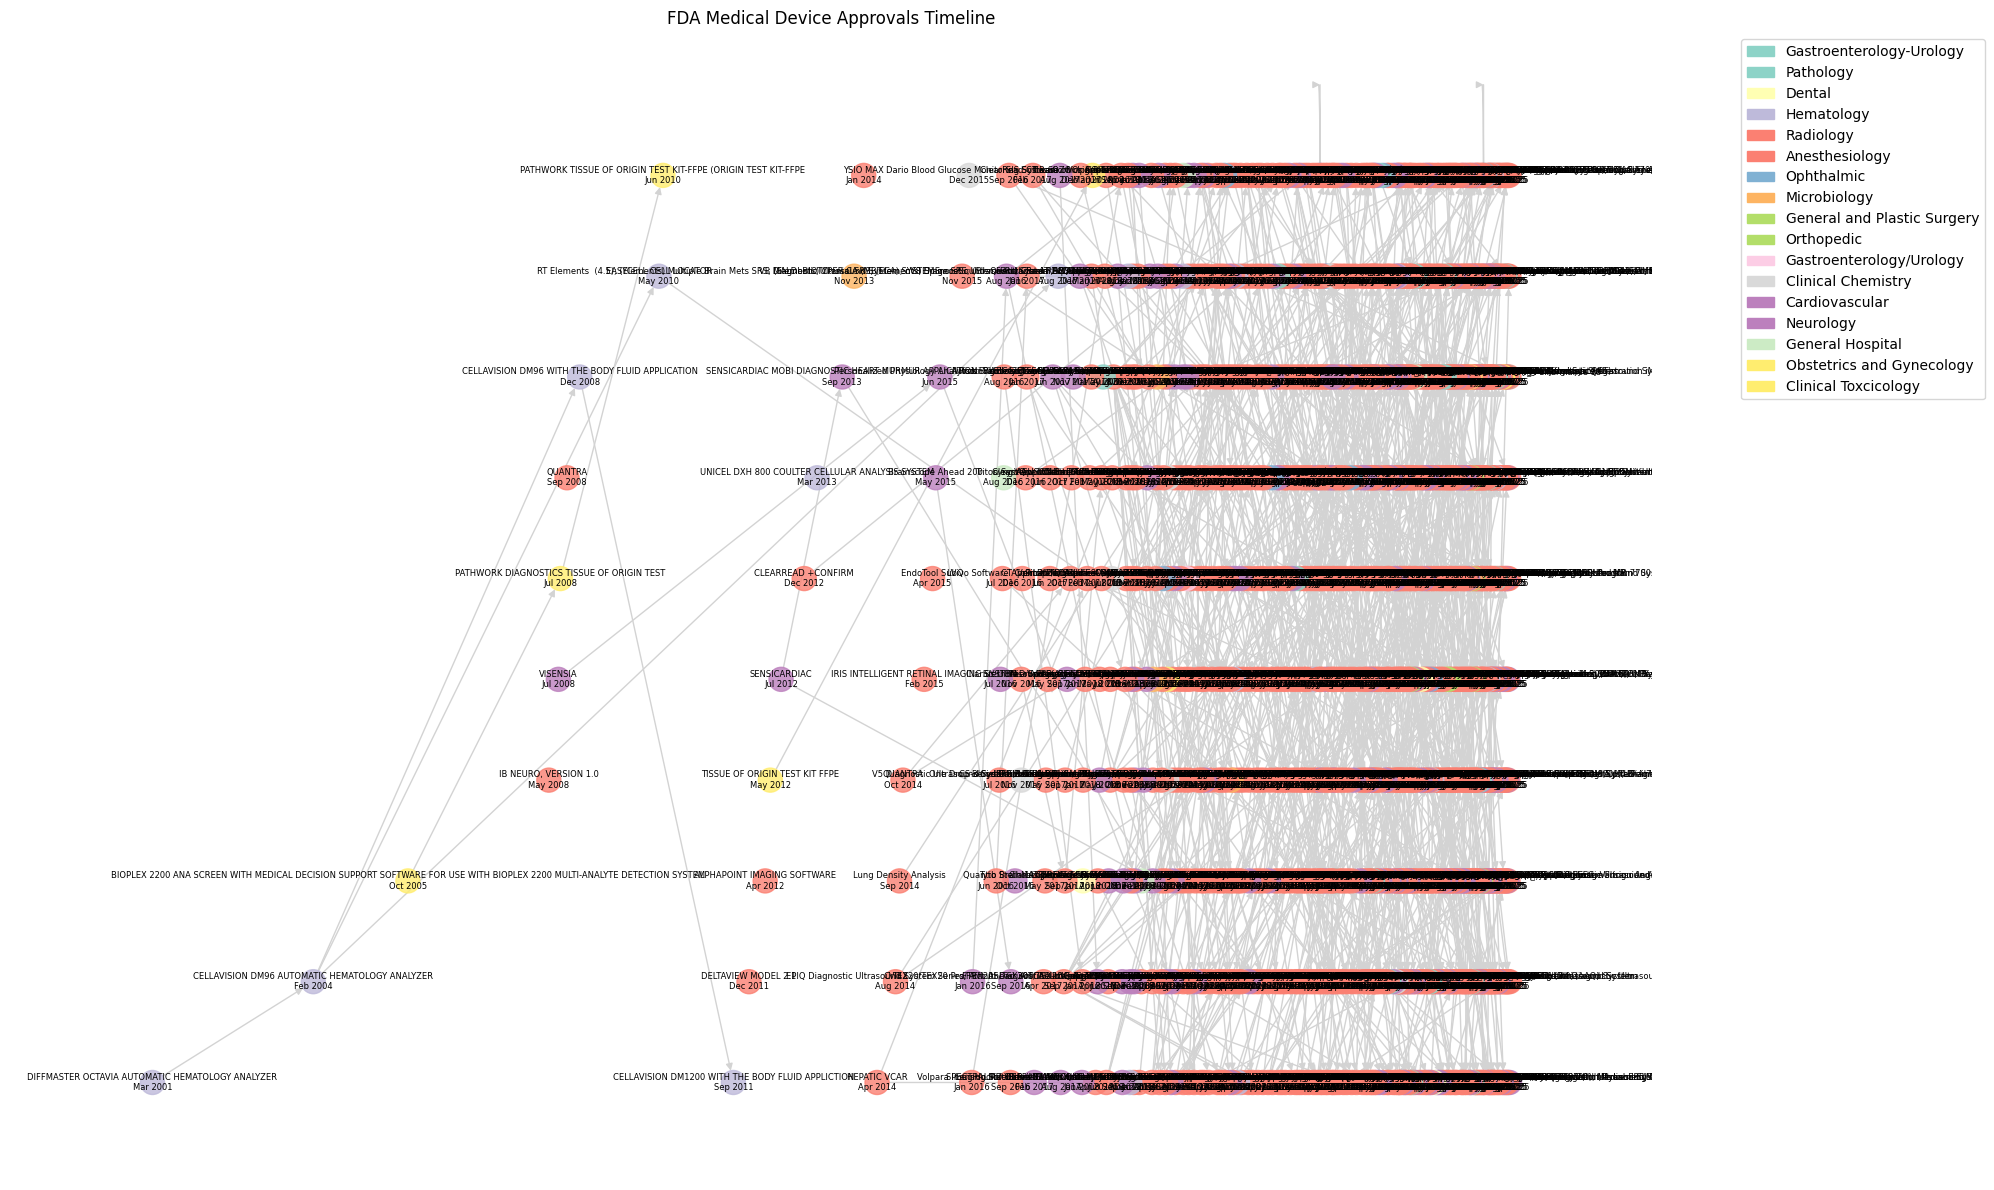

In [5]:
# Install required packages
!pip install networkx matplotlib ipywidgets

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import matplotlib.patches as mpatches
from IPython.display import HTML, display

# Load the CSV file
df = pd.read_csv('/content/dataset-FDA-med-graph.csv', delimiter=';')

# Convert 'Date of Final Decision' to datetime
df['Date of Final Decision'] = pd.to_datetime(df['Date of Final Decision'], format='%d.%m.%Y', errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=['Date of Final Decision'])

# Create a mapping dictionary for nodes to their attributes
node_attrs = {}
for _, row in df.iterrows():
    submission_num = row['Submission Number']
    node_attrs[submission_num] = {
        'Date of Final Decision': row['Date of Final Decision'].strftime('%Y-%m-%d'),
        'Device': row['Device'],
        'Company': row['Company'],
        'Panel': row['Panel (Lead)'],
        'Product_Code': row['Primary Product Code']
    }

# Create the graph
G = nx.DiGraph()

# Add nodes with attributes
for idx, row in df.iterrows():
    submission_num = row['Submission Number']
    G.add_node(submission_num,
               date=row['Date of Final Decision'],
               device=row['Device'],
               company=row['Company'],
               panel=row['Panel (Lead)'],
               product_code=row['Primary Product Code'])

# Process Predicate Device column to create edges
for idx, row in df.iterrows():
    predicate_str = str(row['Predicate Device'])
    if pd.notna(row['Predicate Device']) and predicate_str != 'nan':
        # Split multiple predicates if they exist (separated by semicolon or comma)
        predicates = []
        if ';' in predicate_str:
            predicates = [pred.strip() for pred in predicate_str.split(';')]
        elif ',' in predicate_str:
            predicates = [pred.strip() for pred in predicate_str.split(',')]
        else:
            predicates = [predicate_str.strip()]

        predicates = [p for p in predicates if p]  # Remove empty strings

        # Connect current submission to all predicates
        current_submission = row['Submission Number']
        for pred in predicates:
            if pred in G.nodes:  # Only connect if predicate exists as a node
                G.add_edge(pred, current_submission)

# Prepare visualization data
nodes = list(G.nodes())
dates = [G.nodes[node]['date'] for node in nodes]
devices = [G.nodes[node]['device'] for node in nodes]

# Sort nodes by date for timeline layout
sorted_nodes_with_dates = sorted(zip(nodes, dates), key=lambda x: x[1])
sorted_nodes = [n for n, d in sorted_nodes_with_dates]
sorted_dates = [d for n, d in sorted_nodes_with_dates]

# Create positions for a timeline layout
pos = {}
for i, (node, date) in enumerate(zip(sorted_nodes, sorted_dates)):
    # X position based on date (timeline)
    x_pos = date.timestamp()
    # Y position staggered to avoid overlap
    y_pos = (i % 10) - 5  # Stagger vertically
    pos[node] = (x_pos, y_pos)

# Create color map based on Panel (Lead)
panels = set(df['Panel (Lead)'].dropna())
panel_colors = plt.cm.Set3(np.linspace(0, 1, len(panels)))
panel_color_map = {panel: panel_colors[i] for i, panel in enumerate(panels)}

# Create subgroups based on Primary Product Code within each panel
product_codes = set(df['Primary Product Code'].dropna())
code_colors = plt.cm.tab20(np.linspace(0, 1, len(product_codes)))
code_color_map = {code: code_colors[i] for i, code in enumerate(product_codes)}

# Assign colors to nodes based on their panel and product code
node_colors = []
for node in nodes:
    panel = G.nodes[node]['panel']
    product_code = G.nodes[node]['product_code']
    # Use panel color as base, could blend with product code color if needed
    color = panel_color_map.get(panel, 'gray')
    node_colors.append(color)

# Create labels with Device and Month/Year
labels = {}
for node in nodes:
    device = G.nodes[node]['device']
    date = G.nodes[node]['date']
    month_year = date.strftime('%b %Y')
    labels[node] = f"{device}\n{month_year}"

# Draw the graph
plt.figure(figsize=(20, 12))
ax = plt.gca()

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='lightgray', arrows=True, arrowsize=10, width=1)

# Draw nodes
node_collection = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.8)

# Draw labels
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, font_color='black')

# Create legend
legend_elements = []
for panel, color in panel_color_map.items():
    legend_elements.append(mpatches.Patch(color=color, label=panel))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("FDA Medical Device Approvals Timeline")
plt.axis('off')  # Turn off axis

# Set white background
plt.gcf().patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# For interactive visualization, we'll create an HTML export using pyvis (install it)
!pip install pyvis

from pyvis.network import Network

# Create Pyvis network
net = Network(height="800px", width="100%", bgcolor="white", font_color="black")

# Add nodes with attributes
for node in G.nodes():
    date = G.nodes[node]['date'].strftime('%b %Y')
    device = G.nodes[node]['device']
    company = G.nodes[node]['company']
    panel = G.nodes[node]['panel']
    product_code = G.nodes[node]['product_code']

    title = f"Device: {device}<br>Company: {company}<br>Date: {date}<br>Panel: {panel}<br>Product Code: {product_code}"

    # Get color based on panel
    panel_color = panel_color_map.get(panel, 'gray')
    # Convert RGB to hex
    hex_color = "#{:02x}{:02x}{:02x}".format(int(panel_color[0]*255), int(panel_color[1]*255), int(panel_color[2]*255))

    net.add_node(node, label=f"{device}\n{date}", title=title, color=hex_color)

# Add edges
for edge in G.edges():
    net.add_edge(edge[0], edge[1])

# Save and display
net.save_graph("fda_medical_device_timeline.html")
display(HTML("fda_medical_device_timeline.html"))

### Interactive FDA Medical Device Approvals Timeline

This section generates an interactive timeline visualization of the FDA medical device approvals using the `pyvis` library. The timeline is saved as an HTML file and then displayed.

In [6]:
from pyvis.network import Network
from IPython.display import HTML, display

# Create Pyvis network
net = Network(height="800px", width="100%", bgcolor="white", font_color="black")

# Add nodes with attributes from the existing graph G
for node in G.nodes():
    date = G.nodes[node]['date'].strftime('%b %Y')
    device = G.nodes[node]['device']
    company = G.nodes[node]['company']
    panel = G.nodes[node]['panel']
    product_code = G.nodes[node]['product_code']

    title = f"Device: {device}<br>Company: {company}<br>Date: {date}<br>Panel: {panel}<br>Product Code: {product_code}"

    # Get color based on panel (assuming panel_color_map is still available from previous execution)
    panel_color = panel_color_map.get(panel, 'gray')
    # Convert RGB to hex
    hex_color = "#{:02x}{:02x}{:02x}".format(int(panel_color[0]*255), int(panel_color[1]*255), int(panel_color[2]*255))

    net.add_node(node, label=f"{device}\n{date}", title=title, color=hex_color)

# Add edges from the existing graph G
for edge in G.edges():
    net.add_edge(edge[0], edge[1])

# Save the graph to an HTML file
output_filename = "fda_medical_device_timeline_interactive.html"
net.save_graph(output_filename)

print(f"Interactive timeline saved to {output_filename}")

# Display the interactive HTML in the notebook output
display(HTML(output_filename))

# Optionally, print the raw HTML content if direct display is not working
with open(output_filename, 'r') as f:
    raw_html_content = f.read()
# print("\n--- Raw HTML Content ---\n")
# print(raw_html_content)
# print("\n------------------------")

Interactive timeline saved to fda_medical_device_timeline_interactive.html
